In [65]:
import matplotlib.pyplot as plt
import cv2 as cv
from lcLevy.Image import Img
from skimage.measure import ransac, LineModelND
import numpy as np


In [ ]:
# Currently getting errors in this, but I will fix them later, trust

# uses lclevy cr3 file to extract a high definition jpeg from cr3 file - input a list of paths to convertible files
def parse_imgs(imgs):
    for img in imgs: 
        temp = Img(img, img[20:24])

# given the beginning number and end number of unconverted cr3 images, returns list of file paths 
def stage_imgs(range_begin, range_end):
    return [f"EOS_R100_Images/IMG_{"{:04d}".format(num)}.CR3" for num in range(range_begin, range_end)]

# Img("EOS_R100_Images/IMG_0006.CR3", "0006")

# parse_imgs(stage_imgs(7, 15))

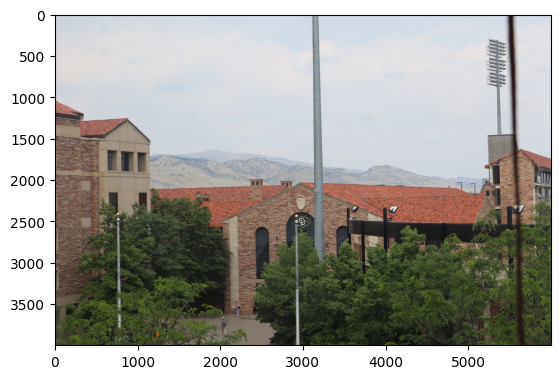

In [ ]:
# Using image of folsom field as test image
image = cv.imread("EOS_R100_JPG/jpg0005.jpg")
image = image[:,:,::-1]
plt.imshow(image)

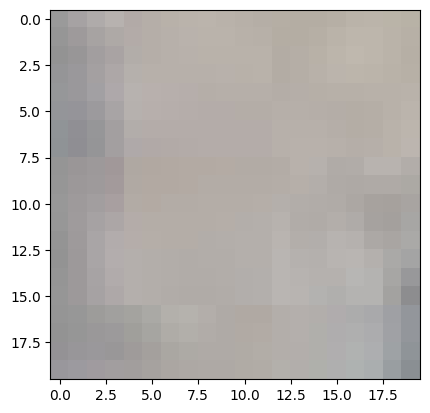

In [19]:
# take a patch of the image - eventually we will analyze all patches, but just want to calculate parameters for this patch right now
# What is the optimal patch size? Is it better to use larger ones or smaller ones?
patch_range = { 
    "minx":1500, 
    "maxx":1520, 
    "miny" : 2000, 
    "maxy": 2020,
    }
patch = image[patch_range["miny"]:patch_range["maxy"],patch_range["minx"]:patch_range["maxx"]]
plt.imshow(patch)

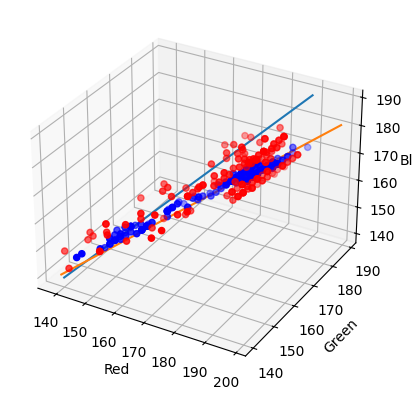

In [58]:
ax = plt.figure().add_subplot(projection = '3d')
ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue")

pixels = patch.reshape(400,3)

# for pix in pixels:
#     ax.scatter(pix[0], pix[1], pix[2], c = "darkblue")

xs = range(140, 190)
ax.plot(xs, xs, xs)

# calculate the line of best fit (with ransac algorithm cos we want to use scikit for something)
# might be something to mess around with different options for later

lobf, inliers = ransac(pixels, LineModelND, 200, 2, max_trials = 1000)

outliers = inliers == False
ax.scatter(pixels[inliers][:, 0], pixels[inliers][:,1], pixels[inliers][:,2], c = "b")
ax.scatter(pixels[outliers][:, 0], pixels[outliers][:, 1], pixels[outliers][:,2], c = "r")

ys = lobf.predict_x(xs)
zs = lobf.predict_y(xs)
ax.plot(ys, xs, zs)
# print(lobf.)

plt.show()
    

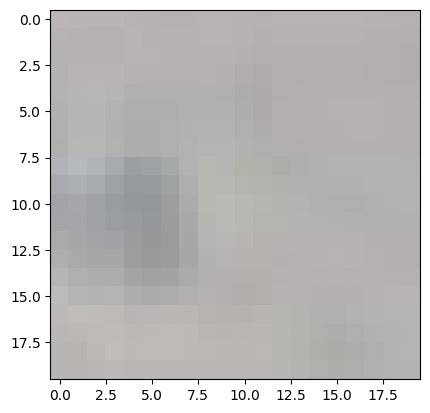

In [62]:
# Take a second patch, Analyze it as well
patch_two_range = { 
    "minx":2980, 
    "maxx":3000, 
    "miny" : 2000, 
    "maxy": 2020,
    }
patch_two = image[patch_two_range["miny"]:patch_two_range["maxy"],patch_two_range["minx"]:patch_two_range["maxx"]]
plt.imshow(patch_two)

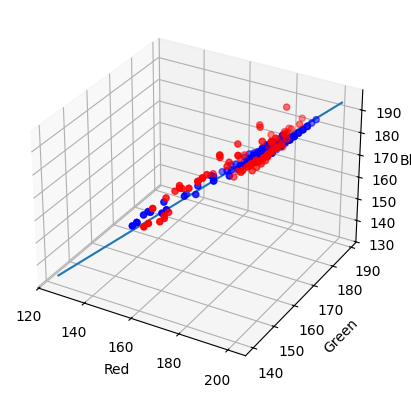

In [69]:
ax = plt.figure().add_subplot(projection = '3d')
ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue")

pixels = patch_two.reshape(400,3)

# for pix in pixels:
#     ax.scatter(pix[0], pix[1], pix[2], c = "darkblue")

ys = range(140, 190)
# ax.plot(xs, xs, xs)

# calculate the line of best fit (with ransac algorithm cos we want to use scikit for something)
# might be something to mess around with different options for later

lobf_two, inliers = ransac(pixels, LineModelND, 200, 2, max_trials = 1000)

outliers = inliers == False
ax.scatter(pixels[inliers][:, 0], pixels[inliers][:,1], pixels[inliers][:,2], c = "b")
ax.scatter(pixels[outliers][:, 0], pixels[outliers][:, 1], pixels[outliers][:,2], c = "r")

# Why are the x and y switched, this might cause errors...
xs = lobf_two.predict_x(xs)
zs = lobf_two.predict_y(xs)
ax.plot(xs, ys, zs)
# print(lobf.)

plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

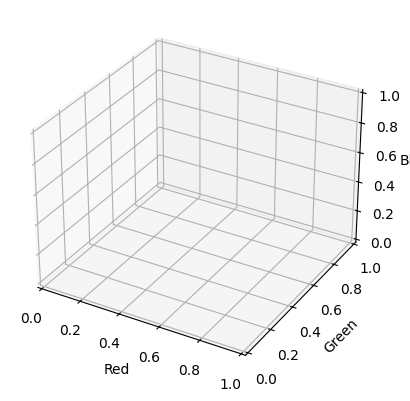

In [ ]:
# Plotting the intersection of the planes to find airlight direction vector
ax = plt.figure().add_subplot(projection = "3d")
ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue")

# plane 1
y1 = 50
pt1 = [lobf.predict_x(y1), y1,lobf.predict_y(y1)]
y2 = 100
pt2 = [lobf.predict_x(y2), y2, lobf.predict_y(y2)]
n1 = np.cross(pt1, pt2)

xs = range(100)
ys = range(100)

z1 = pt1[2]-n1[0]/n1[2](xs - pt1[0])-n1[1]/n1[2](ys-pt1[2])

ax.plot_surface(xs, ys, z1)



plt.show()